In [1]:
%store -r forest_cover_df

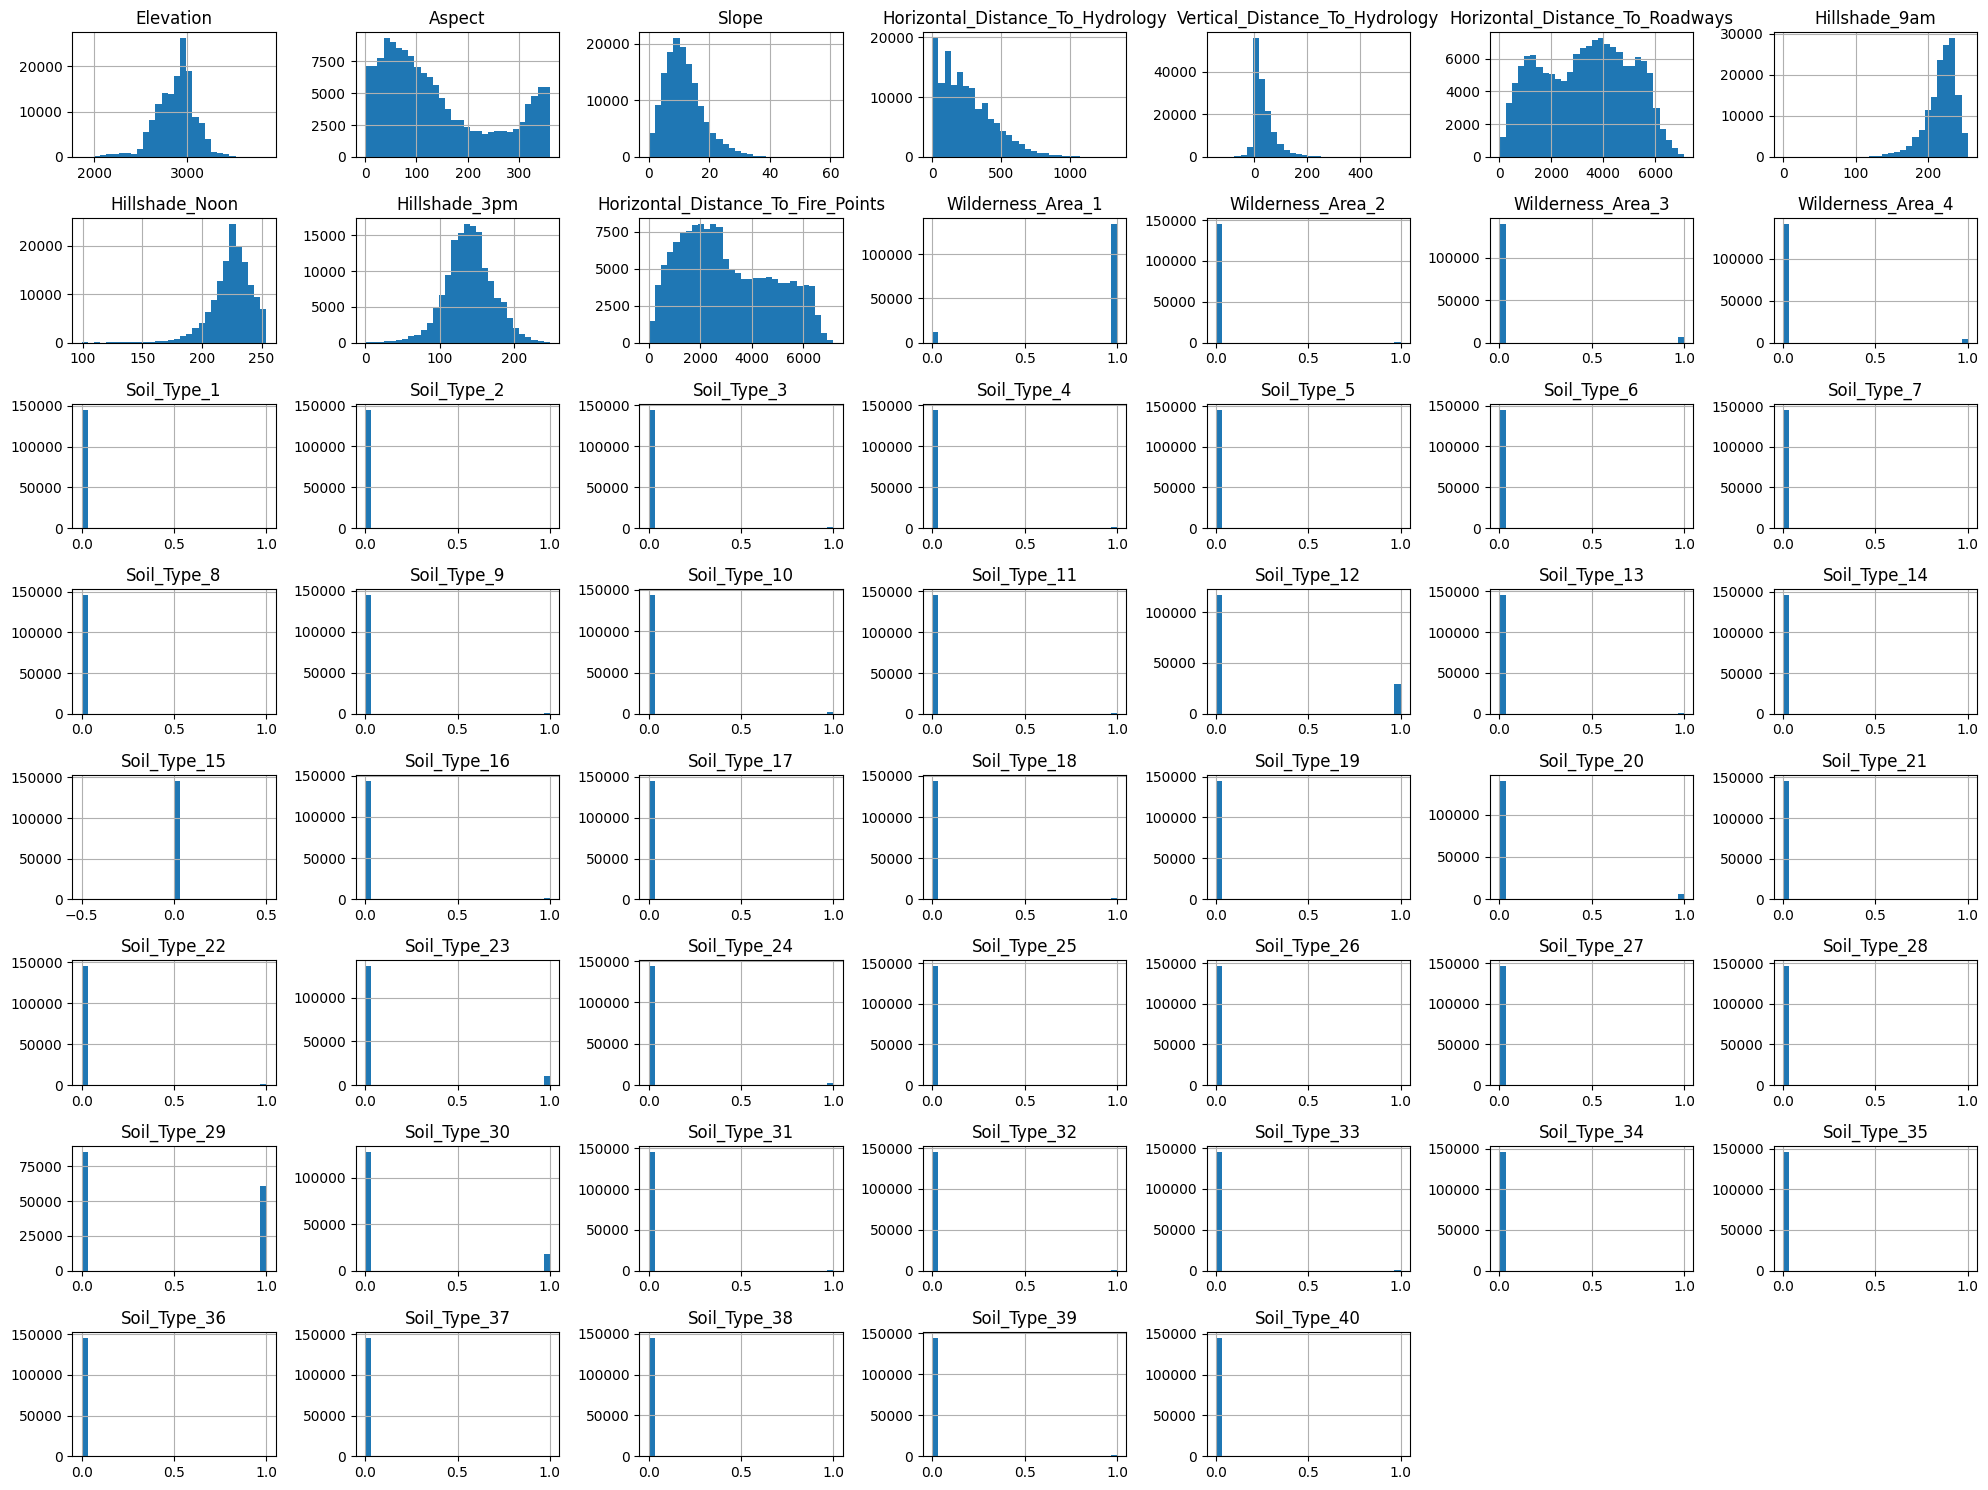

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

num_cols = forest_cover_df.select_dtypes(include=np.number).columns

forest_cover_df[num_cols].hist(figsize=(20,15), bins=30)
plt.tight_layout()
plt.show()

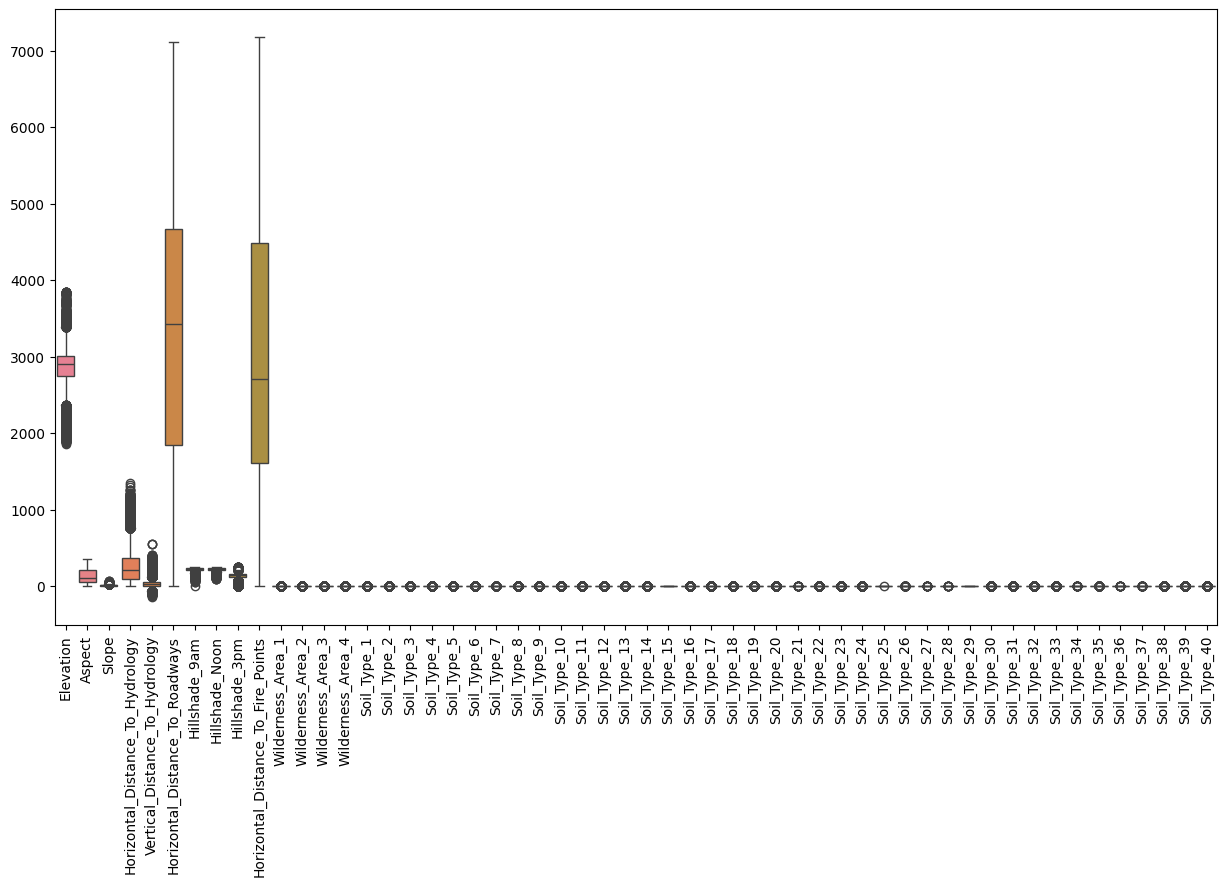

In [3]:
import seaborn as sns
plt.figure(figsize=(15,8))
sns.boxplot(data=forest_cover_df[num_cols])
plt.xticks(rotation=90)
plt.show()

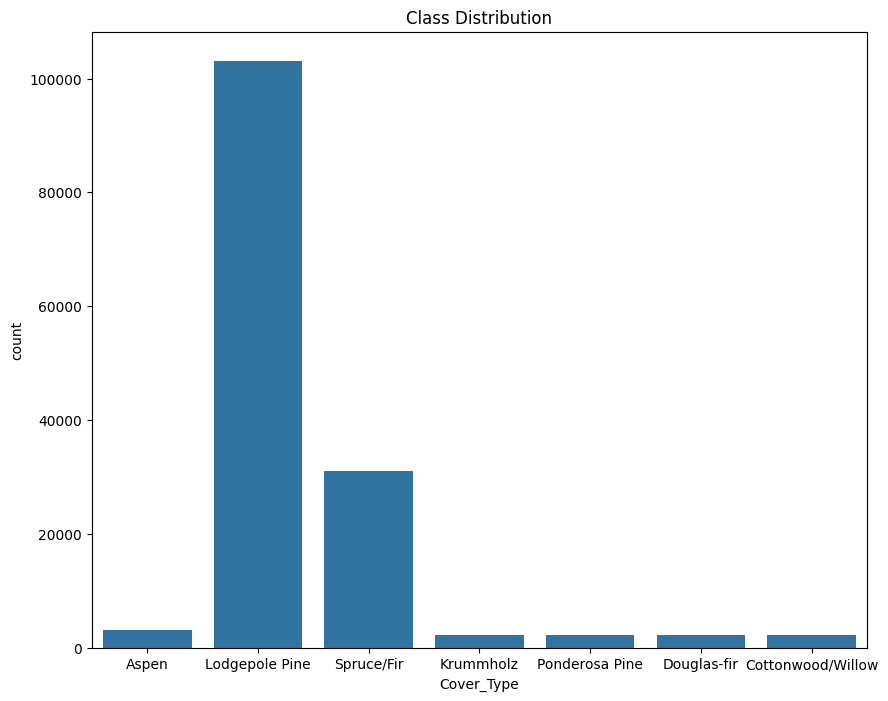

Cover_Type
Lodgepole Pine       103071
Spruce/Fir            31110
Aspen                  3069
Krummholz              2160
Ponderosa Pine         2160
Douglas-fir            2160
Cottonwood/Willow      2160
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(10,8))
sns.countplot(x='Cover_Type', data=forest_cover_df)
plt.title("Class Distribution")
plt.show()

print(forest_cover_df['Cover_Type'].value_counts())

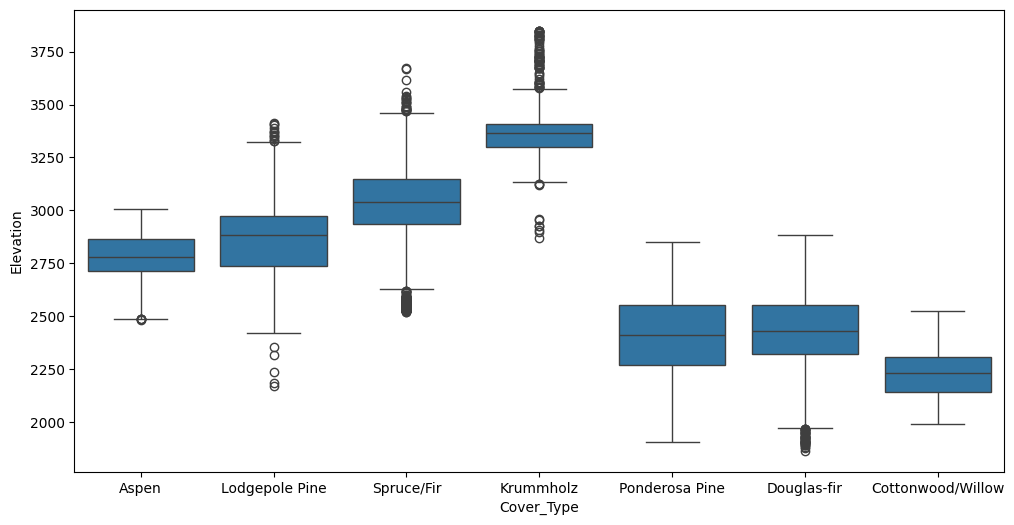

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Cover_Type', y='Elevation', data=forest_cover_df)
plt.show()

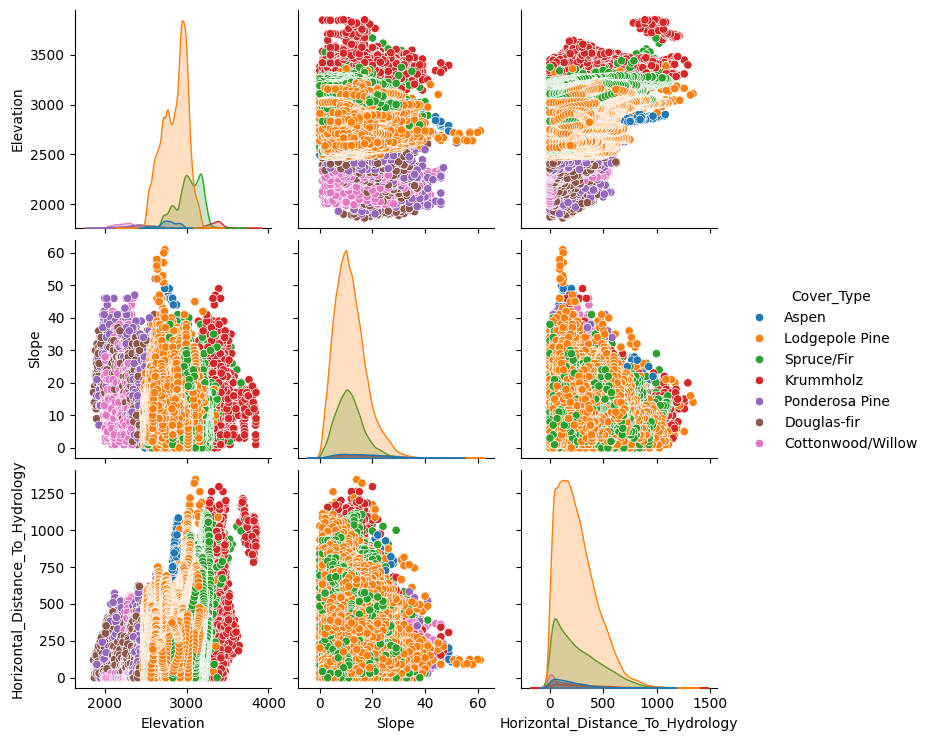

In [6]:
sample_cols = ['Elevation','Slope','Horizontal_Distance_To_Hydrology','Cover_Type']
sns.pairplot(forest_cover_df[sample_cols], hue='Cover_Type')
plt.show()

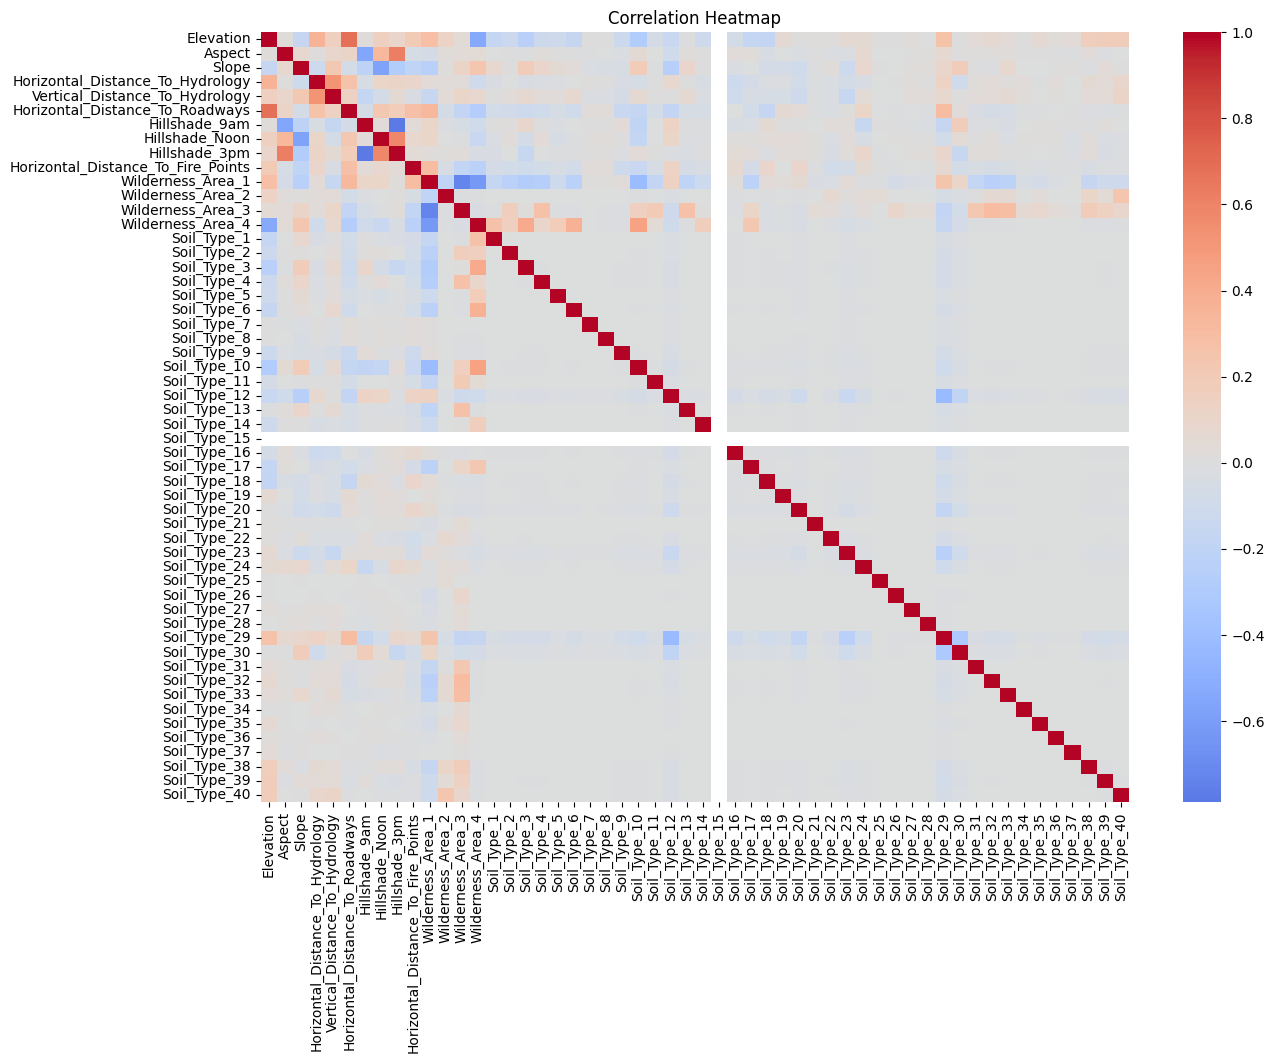

In [7]:
plt.figure(figsize=(14,10))
corr = forest_cover_df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# split
X = forest_cover_df.drop('Cover_Type', axis=1)
y = forest_cover_df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

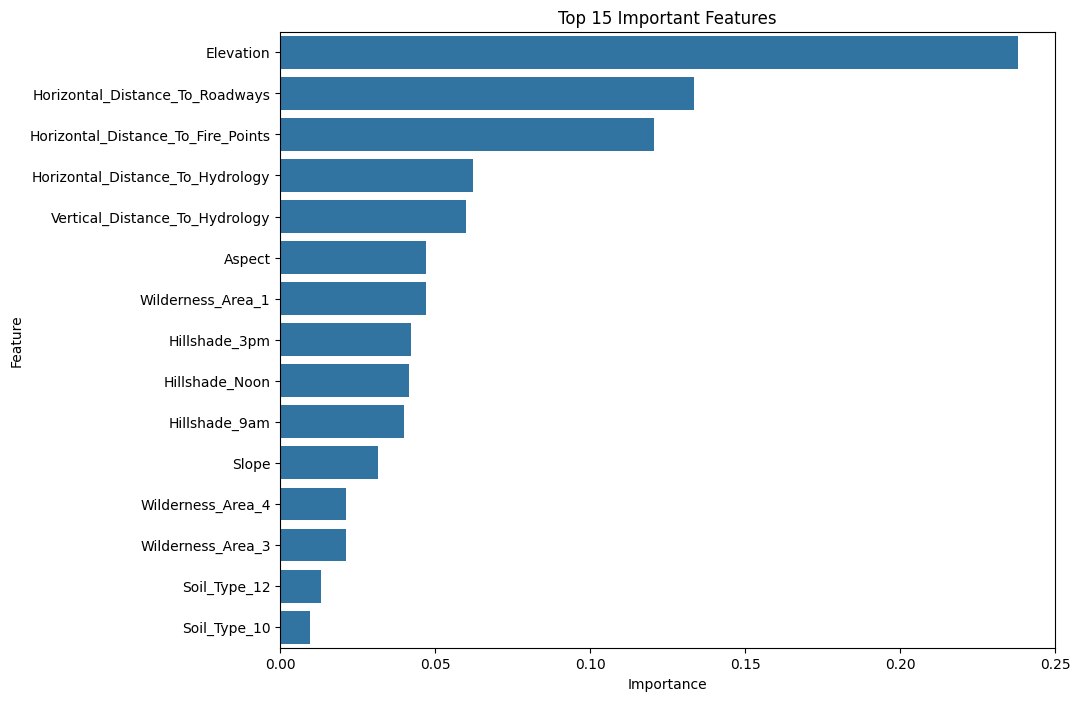

In [9]:
importances = rf.feature_importances_
feat_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feat_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title("Top 15 Important Features")
plt.show()